## We will use this file to generate individual functional data - synonymous, LoF and missense

Refer to Likelihood_NFE.ipynb for synonymous sites; 
Refer to Get_LoF_data_sorted.ipynb for LoF sites

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from scipy.integrate import quad
from scipy.stats import hypergeom
import glob
import os
import math
import re
import ast
import csv
from concurrent.futures import ProcessPoolExecutor
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
from itertools import combinations

In [ ]:
## Load the QC'ed GnomAD dataset

df = pd.read_csv("/home/prk534/Pop_gen_simulator/demograph_Roulette_scaling/gnomad_sfs2_Roulette_QC_AN90.tsv.bgz", sep="\t", compression="gzip")
df

In [3]:
# Check if any of the columns which are concerned with Allele Number is NA
cols_to_check = ['allele_number', 'AN_AFR', 'AN_AMR', 'AN_EAS', 'AN_FIN','AN_NFE', 'AN_SAS', 'allele_count']  # replace with your column names

# Boolean mask where any of the columns is NA
mask = df[cols_to_check].isna().any(axis=1)

# Rows where any selected column is NA
rows_with_na = df[mask]
rows_with_na

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_EAS,AC_FIN,AC_NFE,AC_SAS,consequence,most_severe_consequence,most_severe_consequence2,am,esm1v_neg,esm_neg


In [4]:
# Check: is allele_count all zero where AC_SAS is NaN?
all_zero = (df.loc[df['AC_AMR'].isna(), 'allele_count'] == 0).all()
print(all_zero)  # Output: True

True


In [5]:
# Replace NaN values in AC_[anc] with 0
cols = ['AC_AFR', 'AC_AMR', 'AC_EAS', 'AC_FIN', 'AC_SAS', 'AC_NFE']
df[cols] = df[cols].fillna(0)
df

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_EAS,AC_FIN,AC_NFE,AC_SAS,consequence,most_severe_consequence,most_severe_consequence2,am,esm1v_neg,esm_neg
0,10,49200,C,A,TFBS,0.051,ENSG00000261456,ENST00000568584,0,1426156,...,0.0,0.0,0.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN
1,10,49200,C,G,TFBS,0.041,ENSG00000261456,ENST00000568584,0,1426156,...,0.0,0.0,0.0,0.0,NaN,NaN,synonymous_variant,NaN,NaN,NaN
2,10,49200,C,T,TFBS,0.163,ENSG00000261456,ENST00000568584,0,1426156,...,0.0,0.0,0.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN
3,10,49201,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,0,1426688,...,0.0,0.0,0.0,0.0,missense_variant,missense_variant,missense_variant,0.9877,13.002,14.785
4,10,49201,C,G,TFBS,0.030,ENSG00000261456,ENST00000568584,0,1426688,...,0.0,0.0,0.0,0.0,NaN,NaN,missense_variant,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94769017,9,138121998,A,G,TFBS,0.083,ENSG00000148408,ENST00000371372,0,1443638,...,0.0,0.0,0.0,0.0,NaN,NaN,stop_lost,NaN,NaN,NaN
94769018,9,138121998,A,T,TFBS,0.020,ENSG00000148408,ENST00000371372,0,1443638,...,0.0,0.0,0.0,0.0,NaN,NaN,stop_lost,NaN,NaN,NaN
94769019,9,138121999,G,A,TFBS,0.083,ENSG00000148408,ENST00000371372,102,1443190,...,0.0,0.0,94.0,0.0,stop_retained_variant,stop_retained_variant,stop_retained_variant,NaN,NaN,NaN
94769020,9,138121999,G,C,TFBS,0.062,ENSG00000148408,ENST00000371372,0,1443190,...,0.0,0.0,0.0,0.0,NaN,NaN,stop_lost,NaN,NaN,NaN


### Final synonymous sites

In [ ]:
df_filter_syn = df[df["most_severe_consequence2"] == 'synonymous_variant'].reset_index(drop = True)
df_filter_syn

In [7]:
# Assume df_filter_syn is already loaded
# List of ancestries
ancestries = ['AFR', 'AMR', 'EAS', 'FIN', 'SAS', 'NFE']

# Create output folder if not exists
output_folder = "Data/syn_anc"
os.makedirs(output_folder, exist_ok=True)

# Loop over ancestries
for anc in ancestries:
    ac_col = f"AC_{anc}"
    an_col = f"AN_{anc}"

    if ac_col not in df_filter_syn.columns or an_col not in df_filter_syn.columns:
        print(f"Skipping {anc} — column {ac_col} or {an_col} not found.")
        continue

    # Calculate mode of AN_{anc}
    mode_value = df_filter_syn[an_col].mode().iloc[0]

    # Extract MR and the ancestry-specific AC
    df_syn = df_filter_syn[['MR', ac_col]].copy()
    df_syn = df_syn.rename(columns={ac_col: 'allele_count'})

    # Replace NaN allele counts with 0
    df_syn['allele_count'] = df_syn['allele_count'].fillna(0)

    # Group by MR and allele_count
    df_count = df_syn.groupby(['MR', 'allele_count']).size().reset_index(name='count')

    # Save
    output_file = os.path.join(output_folder, f"{anc}_{mode_value}.txt.gz")
    df_count.to_csv(output_file, sep='\t', index=False, compression='gzip')

    print(f"Saved {output_file}")


Saved Data/syn_anc/AFR_33480.txt.gz
Saved Data/syn_anc/AMR_44724.txt.gz
Saved Data/syn_anc/EAS_39700.txt.gz
Saved Data/syn_anc/FIN_53420.txt.gz
Saved Data/syn_anc/SAS_86258.txt.gz
Saved Data/syn_anc/NFE_1112012.txt.gz


In [8]:
# save the synonymous file as well - Data/synonymous_data.txt.gz
df_filter_syn.to_csv("Data/synonymous_data.txt.gz", sep='\t', index=False, compression='gzip')

ERROR! Session/line number was not unique in database. History logging moved to new session 7056


#### Calculate the SFS (just as above) but for total allele counts and not demography specific.

In [2]:
# Calculate the SFS (just as above) but for total allele counts and not demography specific.

df_filter_syn = pd.read_csv("Data/synonymous_data.txt.gz", sep="\t", compression="gzip")
df_filter_syn

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_EAS,AC_FIN,AC_NFE,AC_SAS,consequence,most_severe_consequence,most_severe_consequence2,am,esm1v_neg,esm_neg
0,10,49200,C,A,TFBS,0.051,ENSG00000261456,ENST00000568584,0,1426156,...,0.0,0.0,0.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN
1,10,49200,C,G,TFBS,0.041,ENSG00000261456,ENST00000568584,0,1426156,...,0.0,0.0,0.0,0.0,NaN,NaN,synonymous_variant,NaN,NaN,NaN
2,10,49200,C,T,TFBS,0.163,ENSG00000261456,ENST00000568584,0,1426156,...,0.0,0.0,0.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN
3,10,49203,G,A,TFBS,1.204,ENSG00000261456,ENST00000568584,7,1427464,...,1.0,0.0,5.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN
4,10,49206,C,T,TFBS,0.163,ENSG00000261456,ENST00000568584,0,1428644,...,0.0,0.0,0.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18551059,9,138121981,C,T,TFBS,0.151,ENSG00000148408,ENST00000371372,1,1447928,...,1.0,0.0,0.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN
18551060,9,138121984,A,G,TFBS,0.062,ENSG00000148408,ENST00000371372,0,1447640,...,0.0,0.0,0.0,0.0,NaN,NaN,synonymous_variant,NaN,NaN,NaN
18551061,9,138121987,C,T,TFBS,0.151,ENSG00000148408,ENST00000371372,0,1447056,...,0.0,0.0,0.0,0.0,NaN,NaN,synonymous_variant,NaN,NaN,NaN
18551062,9,138121990,C,T,TFBS,0.117,ENSG00000148408,ENST00000371372,2,1445666,...,1.0,0.0,1.0,0.0,synonymous_variant,synonymous_variant,synonymous_variant,NaN,NaN,NaN


In [5]:
df_filter_syn["AN_AFR"].mode()

0    33480
Name: AN_AFR, dtype: int64

In [4]:
# Create output folder if not exists
output_folder = "Data/syn_anc"
os.makedirs(output_folder, exist_ok=True)

ac_col = "allele_count"
an_col = "allele_number"

if ac_col not in df_filter_syn.columns or an_col not in df_filter_syn.columns:
    print(f"Skipping — column {ac_col} or {an_col} not found.")

# Calculate mode of AN_{anc}
mode_value = df_filter_syn[an_col].mode().iloc[0]

# Extract MR and the ancestry-specific AC
df_syn = df_filter_syn[['MR', ac_col]].copy()

# Replace NaN allele counts with 0
df_syn['allele_count'] = df_syn['allele_count'].fillna(0)

# Group by MR and allele_count
df_count = df_syn.groupby(['MR', 'allele_count']).size().reset_index(name='count')

# Save
output_file = os.path.join(output_folder, f"all_{mode_value}.txt.gz")
df_count.to_csv(output_file, sep='\t', index=False, compression='gzip')

print(f"Saved {output_file}")


Saved Data/syn_anc/all_1461892.txt.gz


### Final LoF sites

In [9]:
df_filter_LoF = df[(df["most_severe_consequence2"]=='stop_gained') | (df["most_severe_consequence2"]=='splice_donor_variant') | (df['most_severe_consequence2']=='splice_acceptor_variant')].reset_index(drop = True)
df_filter_LoF

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_EAS,AC_FIN,AC_NFE,AC_SAS,consequence,most_severe_consequence,most_severe_consequence2,am,esm1v_neg,esm_neg
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,0.0,0.0,1.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,0.0,0.0,3.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN
2,10,49217,G,A,TFBS,0.117,ENSG00000261456,ENST00000568584,0,1432036,...,0.0,0.0,0.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN
3,10,49232,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,1,1432762,...,0.0,0.0,0.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN
4,10,179992,A,C,high,0.041,ENSG00000015171,ENST00000381604,0,1415244,...,0.0,0.0,0.0,0.0,NaN,NaN,splice_acceptor_variant,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236932,9,138121969,C,G,TFBS,0.041,ENSG00000148408,ENST00000371372,0,1449300,...,0.0,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN
5236933,9,138121982,C,T,TFBS,0.105,ENSG00000148408,ENST00000371372,0,1447812,...,0.0,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN
5236934,9,138121992,G,A,TFBS,0.139,ENSG00000148408,ENST00000371372,0,1445676,...,0.0,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN
5236935,9,138121993,G,A,TFBS,0.186,ENSG00000148408,ENST00000371372,0,1445722,...,0.0,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN


In [10]:
# Assuming df is your DataFrame
unique_MR = df_filter_LoF['MR'].unique()
MR_rank_dict = {value: rank for rank, value in enumerate(sorted(unique_MR))}

# Assign the rank to each row based on 'MR' values
df_filter_LoF['MR_rank'] = df_filter_LoF['MR'].map(MR_rank_dict)
df_filter_LoF

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_FIN,AC_NFE,AC_SAS,consequence,most_severe_consequence,most_severe_consequence2,am,esm1v_neg,esm_neg,MR_rank
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,0.0,1.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN,16
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,0.0,3.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN,12
2,10,49217,G,A,TFBS,0.117,ENSG00000261456,ENST00000568584,0,1432036,...,0.0,0.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN,11
3,10,49232,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,1,1432762,...,0.0,0.0,0.0,stop_gained,stop_gained,stop_gained,NaN,NaN,NaN,3
4,10,179992,A,C,high,0.041,ENSG00000015171,ENST00000381604,0,1415244,...,0.0,0.0,0.0,NaN,NaN,splice_acceptor_variant,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236932,9,138121969,C,G,TFBS,0.041,ENSG00000148408,ENST00000371372,0,1449300,...,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN,4
5236933,9,138121982,C,T,TFBS,0.105,ENSG00000148408,ENST00000371372,0,1447812,...,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN,10
5236934,9,138121992,G,A,TFBS,0.139,ENSG00000148408,ENST00000371372,0,1445676,...,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN,13
5236935,9,138121993,G,A,TFBS,0.186,ENSG00000148408,ENST00000371372,0,1445722,...,0.0,0.0,0.0,NaN,NaN,stop_gained,NaN,NaN,NaN,17


In [12]:
df_filter_LoF_saved = df_filter_LoF[['#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_id', 'transcript_id','allele_count', 'allele_number',
                                    'AN_AFR', 'AN_AMR', 'AN_EAS', 'AN_FIN', 'AN_NFE', 'AN_SAS', 'AC_AFR', 'AC_AMR', 'AC_EAS', 'AC_FIN', 'AC_NFE', 'AC_SAS',
                                    'most_severe_consequence2', 'MR_rank']]
df_filter_LoF_saved

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AN_NFE,AN_SAS,AC_AFR,AC_AMR,AC_EAS,AC_FIN,AC_NFE,AC_SAS,most_severe_consequence2,MR_rank
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,1095622,81732,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,16
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,1096642,81902,1.0,0.0,0.0,0.0,3.0,0.0,stop_gained,12
2,10,49217,G,A,TFBS,0.117,ENSG00000261456,ENST00000568584,0,1432036,...,1097896,82162,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,11
3,10,49232,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,1,1432762,...,1098218,82224,1.0,0.0,0.0,0.0,0.0,0.0,stop_gained,3
4,10,179992,A,C,high,0.041,ENSG00000015171,ENST00000381604,0,1415244,...,1075612,83154,0.0,0.0,0.0,0.0,0.0,0.0,splice_acceptor_variant,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236932,9,138121969,C,G,TFBS,0.041,ENSG00000148408,ENST00000371372,0,1449300,...,1111704,86234,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,4
5236933,9,138121982,C,T,TFBS,0.105,ENSG00000148408,ENST00000371372,0,1447812,...,1111408,86206,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,10
5236934,9,138121992,G,A,TFBS,0.139,ENSG00000148408,ENST00000371372,0,1445676,...,1110504,86128,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,13
5236935,9,138121993,G,A,TFBS,0.186,ENSG00000148408,ENST00000371372,0,1445722,...,1110516,86124,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,17


In [13]:
# save the LoF data
df_filter_LoF_saved.to_csv("Data/gnomad_lof_full.txt.gz", sep='\t', index=False, compression='gzip')

In [ ]:
# Add downsampling to the data

In [3]:
df_LoF = pd.read_csv("Data/gnomad_lof_full.txt.gz", sep = '\t')
df_LoF

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AN_NFE,AN_SAS,AC_AFR,AC_AMR,AC_EAS,AC_FIN,AC_NFE,AC_SAS,most_severe_consequence2,MR_rank
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,1095622,81732,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,16
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,1096642,81902,1.0,0.0,0.0,0.0,3.0,0.0,stop_gained,12
2,10,49217,G,A,TFBS,0.117,ENSG00000261456,ENST00000568584,0,1432036,...,1097896,82162,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,11
3,10,49232,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,1,1432762,...,1098218,82224,1.0,0.0,0.0,0.0,0.0,0.0,stop_gained,3
4,10,179992,A,C,high,0.041,ENSG00000015171,ENST00000381604,0,1415244,...,1075612,83154,0.0,0.0,0.0,0.0,0.0,0.0,splice_acceptor_variant,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236932,9,138121969,C,G,TFBS,0.041,ENSG00000148408,ENST00000371372,0,1449300,...,1111704,86234,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,4
5236933,9,138121982,C,T,TFBS,0.105,ENSG00000148408,ENST00000371372,0,1447812,...,1111408,86206,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,10
5236934,9,138121992,G,A,TFBS,0.139,ENSG00000148408,ENST00000371372,0,1445676,...,1110504,86128,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,13
5236935,9,138121993,G,A,TFBS,0.186,ENSG00000148408,ENST00000371372,0,1445722,...,1110516,86124,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,17


In [10]:
TARGET_AN = 251496

# Pull arrays
M = df_LoF["AN_NFE"].to_numpy(dtype=np.int64)  # population size (total alleles)
K = df_LoF["AC_NFE"].to_numpy(dtype=np.int64)  # number of "successes" (alt alleles)

# Do not upsample: if a site has fewer alleles than TARGET_AN, sample all available
n = np.minimum(M, TARGET_AN).astype(np.int64)

# Optional: reproducible randomness
rng = np.random.default_rng(0)

# Exact: X ~ Hypergeom(M, K, n)
df_LoF["AC_NFE_ds"] = hypergeom.rvs(M=M, n=K, N=n, random_state=rng)

# If you also want the downsampled AN stored:
df_LoF["AN_NFE_ds"] = n
df_LoF

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_AFR,AC_AMR,AC_EAS,AC_FIN,AC_NFE,AC_SAS,most_severe_consequence2,MR_rank,AC_NFE_ds,AN_NFE_ds
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,16,0,251496
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,1.0,0.0,0.0,0.0,3.0,0.0,stop_gained,12,0,251496
2,10,49217,G,A,TFBS,0.117,ENSG00000261456,ENST00000568584,0,1432036,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,11,0,251496
3,10,49232,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,1,1432762,...,1.0,0.0,0.0,0.0,0.0,0.0,stop_gained,3,0,251496
4,10,179992,A,C,high,0.041,ENSG00000015171,ENST00000381604,0,1415244,...,0.0,0.0,0.0,0.0,0.0,0.0,splice_acceptor_variant,4,0,251496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236932,9,138121969,C,G,TFBS,0.041,ENSG00000148408,ENST00000371372,0,1449300,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,4,0,251496
5236933,9,138121982,C,T,TFBS,0.105,ENSG00000148408,ENST00000371372,0,1447812,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,10,0,251496
5236934,9,138121992,G,A,TFBS,0.139,ENSG00000148408,ENST00000371372,0,1445676,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,13,0,251496
5236935,9,138121993,G,A,TFBS,0.186,ENSG00000148408,ENST00000371372,0,1445722,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,17,0,251496


In [12]:
df_LoF[df_LoF["AC_NFE"]>0]

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_AFR,AC_AMR,AC_EAS,AC_FIN,AC_NFE,AC_SAS,most_severe_consequence2,MR_rank,AC_NFE_ds,AN_NFE_ds
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,16,0,251496
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,1.0,0.0,0.0,0.0,3.0,0.0,stop_gained,12,0,251496
29,10,180130,T,C,high,0.062,ENSG00000015171,ENST00000381604,3,1452480,...,0.0,0.0,0.0,0.0,1.0,0.0,splice_donor_variant,6,0,251496
114,10,236837,G,T,high,0.020,ENSG00000015171,ENST00000381604,1,1454198,...,0.0,0.0,0.0,0.0,1.0,0.0,splice_acceptor_variant,2,0,251496
298,10,247434,C,T,TFBS,2.408,ENSG00000015171,ENST00000381604,2,1461792,...,0.0,0.0,0.0,0.0,2.0,0.0,stop_gained,91,2,251496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236881,9,138120765,C,T,high,0.117,ENSG00000148408,ENST00000371372,1,1398516,...,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,11,0,251496
5236882,9,138120776,C,A,high,0.030,ENSG00000148408,ENST00000371372,1,1400712,...,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,3,1,251496
5236913,9,138121736,C,T,TFBS,1.609,ENSG00000148408,ENST00000371372,2,1461108,...,0.0,0.0,0.0,0.0,2.0,0.0,stop_gained,80,2,251496
5236924,9,138121886,C,T,TFBS,0.139,ENSG00000148408,ENST00000371372,1,1460722,...,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,13,0,251496


In [14]:
# save the LoF data
df_LoF.to_csv("Data/gnomad_lof_full.txt.gz", sep='\t', index=False, compression='gzip')

In [2]:
# Add the new LOFTEE track to the data

In [2]:
df_LoF = pd.read_csv("Data/gnomad_lof_full.txt.gz", sep = '\t')
df_LoF

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_AFR,AC_AMR,AC_EAS,AC_FIN,AC_NFE,AC_SAS,most_severe_consequence2,MR_rank,AC_NFE_ds,AN_NFE_ds
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,0.0,0.0,0.0,0.0,1.0,0.0,stop_gained,16,0,251496
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,1.0,0.0,0.0,0.0,3.0,0.0,stop_gained,12,0,251496
2,10,49217,G,A,TFBS,0.117,ENSG00000261456,ENST00000568584,0,1432036,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,11,0,251496
3,10,49232,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,1,1432762,...,1.0,0.0,0.0,0.0,0.0,0.0,stop_gained,3,0,251496
4,10,179992,A,C,high,0.041,ENSG00000015171,ENST00000381604,0,1415244,...,0.0,0.0,0.0,0.0,0.0,0.0,splice_acceptor_variant,4,0,251496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236932,9,138121969,C,G,TFBS,0.041,ENSG00000148408,ENST00000371372,0,1449300,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,4,0,251496
5236933,9,138121982,C,T,TFBS,0.105,ENSG00000148408,ENST00000371372,0,1447812,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,10,0,251496
5236934,9,138121992,G,A,TFBS,0.139,ENSG00000148408,ENST00000371372,0,1445676,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,13,0,251496
5236935,9,138121993,G,A,TFBS,0.186,ENSG00000148408,ENST00000371372,0,1445722,...,0.0,0.0,0.0,0.0,0.0,0.0,stop_gained,17,0,251496


In [3]:
# New LOFTEE tracks
df_LOFTEE = pd.read_csv("Data/LoF/loftee_final.tsv.gz", sep = '\t')
df_LOFTEE

,chrom,pos,ref,alt,transcript_id,gene_id,gene_symbol,relaxed,strict
0,chr1,65434,G,A,ENST00000641515,ENSG00000186092,OR4F5,False,False
1,chr1,65434,G,C,ENST00000641515,ENSG00000186092,OR4F5,False,False
2,chr1,65434,G,T,ENST00000641515,ENSG00000186092,OR4F5,False,False
3,chr1,65435,T,A,ENST00000641515,ENSG00000186092,OR4F5,False,False
4,chr1,65435,T,C,ENST00000641515,ENSG00000186092,OR4F5,False,False
...,...,...,...,...,...,...,...,...,...
6428415,chrM,15873,T,G,ENST00000361789,ENSG00000198727,MT-CYB,False,False
6428416,chrM,15878,A,T,ENST00000361789,ENSG00000198727,MT-CYB,False,False
6428417,chrM,15879,A,G,ENST00000361789,ENSG00000198727,MT-CYB,False,False
6428418,chrM,15881,T,A,ENST00000361789,ENSG00000198727,MT-CYB,False,False


In [5]:
df_LOFTEE["chrom"].unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22',
       'chrX', 'chrY', 'chrM'], dtype=object)

In [5]:
# Extract digits after 'chr'
df_LOFTEE["#CHROM"] = (df_LOFTEE["chrom"].str.extract(r"^chr(\d+)$").astype(float))
# Drop non-autosomal chromosomes (X, Y, M)
df_LOFTEE = df_LOFTEE[df_LOFTEE["#CHROM"].notna()]
# Convert to integer
df_LOFTEE["#CHROM"] = df_LOFTEE["#CHROM"].astype(int)
df_LOFTEE = df_LOFTEE.rename(columns={"pos": "POS", "ref": "REF", "alt": "ALT"})
df_LOFTEE = df_LOFTEE.drop(columns = ["chrom"])

/tmp/ipykernel_4029393/2069457278.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_LOFTEE["#CHROM"] = df_LOFTEE["#CHROM"].astype(int)


In [11]:
df_LoF_LOFTEE = df_LoF.merge(df_LOFTEE[["#CHROM", "POS", "REF", "ALT", "gene_id", "relaxed"]], on = ["#CHROM", "POS", "REF", "ALT", "gene_id"], how = "left")

In [23]:
df_LoF_filtered = df_LoF_LOFTEE[df_LoF_LOFTEE["relaxed"] == True].reset_index(drop = True)
df_LoF_filtered = df_LoF_filtered.drop(columns = ["relaxed"])
print(df_LoF_filtered.columns)
print(df_LoF.columns)

Index(['#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_id', 'transcript_id',
       'allele_count', 'allele_number', 'AN_AFR', 'AN_AMR', 'AN_EAS', 'AN_FIN',
       'AN_NFE', 'AN_SAS', 'AC_AFR', 'AC_AMR', 'AC_EAS', 'AC_FIN', 'AC_NFE',
       'AC_SAS', 'most_severe_consequence2', 'MR_rank', 'AC_NFE_ds',
       'AN_NFE_ds'],
      dtype='object')
Index(['#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_id', 'transcript_id',
       'allele_count', 'allele_number', 'AN_AFR', 'AN_AMR', 'AN_EAS', 'AN_FIN',
       'AN_NFE', 'AN_SAS', 'AC_AFR', 'AC_AMR', 'AC_EAS', 'AC_FIN', 'AC_NFE',
       'AC_SAS', 'most_severe_consequence2', 'MR_rank', 'AC_NFE_ds',
       'AN_NFE_ds'],
      dtype='object')


In [25]:
# save the LoF data
df_LoF_filtered.to_csv("Data/gnomad_lof_LOFTEE_relaxed.txt.gz", sep='\t', index=False, compression='gzip')

# Missense sites

In [2]:
cols = pd.read_csv("Data/missense/all-models-no-PAI3D_Roulette_annots.txt.gz", sep="\t", compression = "gzip", nrows=0).columns.tolist()
print(cols)

['#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_symbol', 'uniprot_id', 'uniprot_aa_pos', 'uniprot_aa_ref', 'uniprot_aa_alt', 'ensembl_pid', 'ensembl_aa_pos', 'ensembl_aa_ref', 'ensembl_aa_alt', 'ensembl_gid', 'ensembl_tid', 'uniprot_name', 'esm_score', 'proteinmpnn_llr', 'am_pathogenicity', 'rasp_score', 'MisFit_S', 'MisFit_D', 'popeve', 'eve', 'esm1_v', 'mpc', 'esm_score_neg', 'proteinmpnn_llr_neg', 'popeve_neg', 'esm1_v_neg', 'allele_count', 'allele_number', 'most_severe_consequence2']


In [6]:
# New scores collated together
with open(f"/n/scratch/users/p/prk534/Missense/new_scores.pkl", "rb") as f:
    df_scores_fil = pickle.load(f)

print("Done")

df_scores_fil = df_scores_fil[~(df_scores_fil["#CHROM"].isin(["X", "Y"]))]
df_scores_fil = df_scores_fil.drop(columns = ['locus', 'alleles', 'uniprot_base', 'mane_enst', 'canon_enst', 'all_enst', 'mane_NM', 
                                            'mane_select', 'canonical', 'AM', 'EVE', 'esm1b_neg', 'MisFit_S', 'MisFit_D'])


Done


In [3]:
use_cols = ['#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_symbol', 'ensembl_gid',
            'am_pathogenicity', 'esm_score_neg', 'mpc', 'allele_count', 'allele_number', 'most_severe_consequence2']
df_full_AC = pd.read_csv("Data/missense/all-models-no-PAI3D_Roulette_annots.txt.gz", sep = "\t", compression = "gzip", usecols=use_cols)
df_full_AC.head()

/tmp/ipykernel_638913/2070386682.py:3: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full_AC = pd.read_csv("Data/missense/all-models-no-PAI3D_Roulette_annots.txt.gz", sep = "\t", compression = "gzip", usecols=use_cols)


,#CHROM,POS,REF,ALT,QUAL,MR,gene_symbol,ensembl_gid,am_pathogenicity,mpc,esm_score_neg,allele_count,allele_number,most_severe_consequence2
0,10,49200,C,A,TFBS,0.051,TUBB8,ENSG00000261456,NaN,NaN,NaN,0.0,1426156.0,synonymous_variant
1,10,49200,C,G,TFBS,0.041,TUBB8,ENSG00000261456,NaN,NaN,NaN,0.0,1426156.0,synonymous_variant
2,10,49200,C,T,TFBS,0.163,TUBB8,ENSG00000261456,NaN,NaN,NaN,0.0,1426156.0,synonymous_variant
3,10,49201,C,A,TFBS,0.030,TUBB8,ENSG00000261456,0.9877,2.0002,14.785,0.0,1426688.0,missense_variant
4,10,49201,C,G,TFBS,0.030,TUBB8,ENSG00000261456,0.9036,1.4673,12.022,0.0,1426688.0,missense_variant


In [7]:
df_scores_fil.columns

Index(['ensg', 'proteinmpnn_llr_neg', 'revel', 'rasp_score', 'AM',
       'polyphen_score', 'cpt1_score', 'popEVE_neg', 'ESM_1v_neg', 'mpc',
       'cadd_score', 'gpn_msa_score', '#CHROM', 'POS', 'REF', 'ALT'],
      dtype='object')

In [8]:
df_scores_fil[df_scores_fil["ensg"] == "ENSG00000150991"]

,ensg,proteinmpnn_llr_neg,revel,rasp_score,AM,polyphen_score,cpt1_score,popEVE_neg,ESM_1v_neg,mpc,cadd_score,gpn_msa_score,#CHROM,POS,REF,ALT
50795855,ENSG00000150991,0.17928,0.373,-0.33856,0.1442,0.067,0.13275,4.806,0.956,2.16290,2.4815,-6.70,12,124911718,A,C
50795856,ENSG00000150991,-0.22880,0.161,-0.41456,0.1826,0.015,0.10399,4.652,1.513,1.60380,1.8501,-5.67,12,124911718,A,G
50795857,ENSG00000150991,1.58140,0.394,-0.85710,0.4335,0.049,0.23834,4.358,2.736,2.53220,2.6560,-6.05,12,124911718,A,T
50795858,ENSG00000150991,1.80400,0.247,-0.17522,0.1778,0.184,0.11185,4.427,2.180,1.87340,2.1305,-4.67,12,124911719,C,A
50795859,ENSG00000150991,0.22222,0.069,-0.63478,0.1319,0.011,0.14331,4.392,0.933,1.48640,1.9331,-6.07,12,124911719,C,G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50800369,ENSG00000150991,1.24770,0.432,-0.70396,0.6912,0.175,0.37289,4.878,8.799,1.59520,4.8969,-12.16,12,124913767,T,A
50800370,ENSG00000150991,1.56540,0.371,0.16570,0.8665,0.017,0.37881,4.276,8.383,0.97122,4.6722,-10.08,12,124913767,T,C
50800371,ENSG00000150991,2.60940,0.474,2.80150,0.7444,0.598,0.51136,5.112,9.692,1.41170,5.4618,-11.03,12,124913767,T,G
50800372,ENSG00000150991,0.37920,0.296,0.66299,0.4539,0.115,0.45887,4.842,9.426,1.00370,4.6193,-11.45,12,124913768,G,C


In [4]:
df_full_AC_mis = df_full_AC[df_full_AC["most_severe_consequence2"]=="missense_variant"].reset_index(drop = True)
df_full_AC_mis = df_full_AC_mis.rename(columns = {"ensembl_gid": "ensg", "mpc": "MPC"})
df_full_AC_mis.head()

,#CHROM,POS,REF,ALT,QUAL,MR,gene_symbol,ensg,am_pathogenicity,MPC,esm_score_neg,allele_count,allele_number,most_severe_consequence2
0,10,49201,C,A,TFBS,0.030,TUBB8,ENSG00000261456,0.9877,2.0002,14.785,0.0,1426688.0,missense_variant
1,10,49201,C,G,TFBS,0.030,TUBB8,ENSG00000261456,0.9036,1.4673,12.022,0.0,1426688.0,missense_variant
2,10,49201,C,T,TFBS,0.139,TUBB8,ENSG00000261456,0.9907,1.9442,14.372,3.0,1426688.0,missense_variant
3,10,49202,C,A,TFBS,0.062,TUBB8,ENSG00000261456,0.9948,2.3815,15.207,0.0,1427068.0,missense_variant
4,10,49202,C,G,TFBS,0.105,TUBB8,ENSG00000261456,0.9762,1.6435,13.378,0.0,1427068.0,missense_variant


In [5]:
df_score_AC = df_scores_fil.merge(df_full_AC_mis, on = ["#CHROM", "POS", "REF", "ALT", "ensg"], how = "left")

In [6]:
use_cols = ['Chrom', 'Pos', 'Ref', 'Alt', 'Symbol', 'GeneID', 'TranscriptID', 'MisFit_D', 'MisFit_S']

df_misfit = pd.read_csv("Data/missense/MisFit_V1.5_SNV.txt.gz", sep = "\t", compression = "gzip", usecols=use_cols)

df_misfit = df_misfit.rename(columns = {"Chrom": "#CHROM", "Pos": "POS", "Ref": "REF", "Alt": "ALT", "GeneID": "ensg"})
df_misfit = df_misfit[~(df_misfit["#CHROM"].isin(["X", "Y", "MT"]))].reset_index(drop = True)
df_misfit["#CHROM"] = df_misfit["#CHROM"].astype(int)

df_combined = df_score_AC.merge(df_misfit[['#CHROM', 'POS', 'REF', 'ALT', 'ensg', 'MisFit_D', 'MisFit_S']],
                                on = ['#CHROM', 'POS', 'REF', 'ALT', 'ensg'], how = "left")

/tmp/ipykernel_239250/2877203755.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_misfit = pd.read_csv("Data/missense/MisFit_V1.5_SNV.txt.gz", sep = "\t", compression = "gzip", usecols=use_cols)


In [10]:
df_combined.columns

Index(['ensg', 'proteinmpnn_llr_neg', 'revel', 'rasp_score', 'polyphen_score',
       'cpt1_score', 'popEVE_neg', 'ESM_1v_neg', 'mpc', 'cadd_score',
       'gpn_msa_score', '#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR',
       'gene_symbol', 'am_pathogenicity', 'MPC', 'esm_score_neg',
       'allele_count', 'allele_number', 'most_severe_consequence2', 'MisFit_D',
       'MisFit_S'],
      dtype='object')

In [13]:
df_combined = df_combined.drop(columns=["mpc"])

In [14]:
# with open(f"/n/scratch/users/p/prk534/Missense/missense_AC_scores.pkl", "wb") as f:
#     pickle.dump(df_combined, f)

# print("Done")

Done


In [11]:
# Get Revel, Primate 3D

df_AM = pd.read_csv("/home/prk534/Pop_gen_simulator/selection/Missense/scores_RQC_format.txt.gz", sep="\t", compression="gzip")
df_AM

,#CHROM,POS,INFO,REF,ALT,AlphaMissense,PrimateAI-3D,REVEL,LOFTEE-flag,Synonymous-flag,ensembl_gene_id,RouletteMR,RouletteQual
0,10,49200,.,C,A,NaN,NaN,NaN,NaN,1.0,ENSG00000261456,0.051,1
1,10,49200,.,C,G,NaN,NaN,NaN,NaN,1.0,ENSG00000261456,0.041,1
2,10,49200,.,C,T,NaN,NaN,NaN,NaN,1.0,ENSG00000261456,0.163,1
3,10,49201,.,C,A,0.988,0.883,0.663,NaN,NaN,ENSG00000261456,0.030,1
4,10,49201,.,C,G,0.904,0.744,0.615,NaN,NaN,ENSG00000261456,0.030,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91971965,9,117848130,.,G,A,NaN,NaN,NaN,NaN,1.0,ENSG00000285082,0.261,1
91971966,9,117848130,.,G,C,NaN,NaN,NaN,NaN,1.0,ENSG00000285082,0.030,1
91971967,9,117848130,.,G,T,NaN,NaN,NaN,NaN,1.0,ENSG00000285082,0.128,1
91971968,9,117848133,.,T,C,NaN,NaN,NaN,NaN,1.0,ENSG00000285082,0.236,1


In [15]:
# Ensure the key columns are strings or consistent types if needed
df_AM = df_AM.rename(columns={"ensembl_gene_id": "ensg"})

# Perform a left merge to preserve all rows in df_mis_filtered
df_merged = df_combined.merge(
    df_AM[["#CHROM", "POS", "REF", "ALT", "PrimateAI-3D", "REVEL", "ensg"]],
    on= ["#CHROM", "POS", "REF", "ALT", "ensg"],
    how="left"
)

In [39]:
df_merged = df_merged.drop(columns=["revel"])

In [40]:
df_merged = df_merged.drop(columns=["most_severe_consequence2"])
df_merged = df_merged.rename(columns={"ensg": "gene_id", "am_pathogenicity": "AlphaMissense"})

In [41]:
df_merged.to_csv("Data/missense/df_missense_AC.txt.gz", sep="\t", index=False, compression="gzip")

# Scratch

In [44]:
len(df_merged.dropna(subset = ["allele_count", "AlphaMissense", "popEVE_neg", "ESM_1v_neg", "esm_score_neg", "REVEL", "MPC", "MisFit_S", "MisFit_D", "cadd_score", "PrimateAI-3D", "gpn_msa_score"]))

49508722

In [38]:
df_merged.columns

Index(['ensg', 'proteinmpnn_llr_neg', 'revel', 'rasp_score', 'polyphen_score',
       'cpt1_score', 'popEVE_neg', 'ESM_1v_neg', 'cadd_score', 'gpn_msa_score',
       '#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_symbol',
       'am_pathogenicity', 'MPC', 'esm_score_neg', 'allele_count',
       'allele_number', 'most_severe_consequence2', 'MisFit_D', 'MisFit_S',
       'PrimateAI-3D', 'REVEL'],
      dtype='object')

In [18]:
df_nonna = df_merged.dropna(subset = ["allele_count"])
df_nonna[df_nonna.duplicated(subset=["#CHROM", "POS", "REF", "ALT"], keep=False)]

,ensg,proteinmpnn_llr_neg,revel,rasp_score,polyphen_score,cpt1_score,popEVE_neg,ESM_1v_neg,cadd_score,gpn_msa_score,...,am_pathogenicity,MPC,esm_score_neg,allele_count,allele_number,most_severe_consequence2,MisFit_D,MisFit_S,PrimateAI-3D,REVEL
3885694,ENSG00000282608,2.6696,0.231,0.153590,0.625,0.28705,4.427,5.719,6.5644,-12.73,...,0.5034,0.81796,10.054,0.0,1460888.0,missense_variant,0.681992,0.000596,NaN,NaN
3885695,ENSG00000121933,NaN,0.231,NaN,0.852,NaN,NaN,NaN,6.5644,-12.73,...,0.5034,0.81796,10.054,0.0,1460888.0,missense_variant,NaN,NaN,0.608,0.231
3885696,ENSG00000282608,1.8578,0.360,0.903370,0.505,0.16588,4.330,3.358,6.2743,-12.47,...,0.4065,0.57630,7.599,0.0,1460888.0,missense_variant,0.511458,0.000381,NaN,NaN
3885697,ENSG00000121933,NaN,0.360,NaN,0.423,NaN,NaN,NaN,6.2743,-12.47,...,0.4065,0.57630,7.599,0.0,1460888.0,missense_variant,NaN,NaN,0.537,0.360
3885698,ENSG00000282608,1.2302,0.093,0.451880,0.289,0.15363,4.266,1.905,5.6089,-10.37,...,0.2478,0.08635,5.325,0.0,1460888.0,missense_variant,0.387148,0.000276,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75344971,ENSG00000099899,1.7971,0.290,0.079167,0.935,0.31214,3.984,7.152,4.3871,-7.51,...,0.4607,0.27323,11.714,0.0,1460288.0,missense_variant,0.500745,0.001103,0.756,0.290
75344972,ENSG00000099901,NaN,0.145,NaN,0.039,NaN,3.839,1.242,4.6414,-5.91,...,0.9424,0.77517,11.966,0.0,1460288.0,missense_variant,NaN,NaN,NaN,NaN
75344973,ENSG00000099899,-0.2912,0.378,0.912290,0.990,0.35690,4.334,9.153,4.6414,-5.91,...,0.9424,0.77517,11.966,0.0,1460288.0,missense_variant,0.517369,0.001195,0.847,0.378
75344974,ENSG00000099901,NaN,0.125,NaN,0.055,NaN,3.874,1.396,4.2065,-7.33,...,0.4556,0.35374,11.488,0.0,1460288.0,missense_variant,NaN,NaN,NaN,NaN


In [24]:
df_nonna_misfit = df_merged[(df_merged["revel"].notna()) & (df_merged["REVEL"].notna())][["#CHROM", "POS", "REF", "ALT", "ensg", "REVEL", "revel", "gene_symbol"]]

In [25]:
mask_diff = ~np.isclose(df_nonna_misfit["revel"], df_nonna_misfit["REVEL"], atol=9e-03, equal_nan=True)
df_diff = df_nonna_misfit[mask_diff]

In [26]:
print(len(df_diff))
print(df_diff["gene_symbol"].unique())

1703571
['SAMD11' nan 'AGRN' ... 'NCAPH2' 'ODF3B' 'ACR']


In [37]:
df_diff[df_diff["gene_symbol"]=="ODF3B"].head(100)

,#CHROM,POS,REF,ALT,ensg,REVEL,revel,gene_symbol
76819794,22,50530484,T,A,ENSG00000177989,0.081,0.037,ODF3B
76819796,22,50530484,T,G,ENSG00000177989,0.081,0.033,ODF3B
76819798,22,50530485,T,C,ENSG00000177989,0.031,0.003,ODF3B
76819799,22,50530485,T,G,ENSG00000177989,0.041,0.015,ODF3B
76819806,22,50530488,C,G,ENSG00000177989,0.103,0.055,ODF3B
...,...,...,...,...,...,...,...,...
76820429,22,50530837,C,T,ENSG00000177989,0.069,0.080,ODF3B
76820431,22,50530838,G,C,ENSG00000177989,0.029,0.268,ODF3B
76820436,22,50530840,A,C,ENSG00000177989,0.039,0.111,ODF3B
76820437,22,50530840,A,G,ENSG00000177989,0.106,0.182,ODF3B


In [6]:
cols = pd.read_csv("/n/scratch/users/p/prk534/Missense/pd_vsm_all_SNP_gene_la.bgz", sep="\t", compression = "gzip", nrows=5)
cols.iloc[0:5, 9:25]

,uniprot_base,mane_enst,canon_enst,all_enst,mane_NM,mane_select,canonical,mane_uniprot_iso_em,canon_uniprot_iso_em,all_uniprot_iso_em,transcript_mane_select,mane_or_canon_enst,proteinmpnn_llr_neg,esm1b_neg,revel,rasp_score
0,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,A0A2U3U0J3,A0A2U3U0J3,"[""A0A2U3U0J3""]",True,ENST00000641515,NaN,NaN,NaN,NaN
1,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,A0A2U3U0J3,A0A2U3U0J3,"[""A0A2U3U0J3""]",True,ENST00000641515,NaN,NaN,NaN,NaN
2,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,A0A2U3U0J3,A0A2U3U0J3,"[""A0A2U3U0J3""]",True,ENST00000641515,NaN,NaN,NaN,NaN
3,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,A0A2U3U0J3,A0A2U3U0J3,"[""A0A2U3U0J3""]",True,ENST00000641515,NaN,NaN,NaN,NaN
4,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,A0A2U3U0J3,A0A2U3U0J3,"[""A0A2U3U0J3""]",True,ENST00000641515,NaN,NaN,NaN,NaN


In [11]:
df_head = pd.read_csv("/n/scratch/users/p/prk534/Missense/AlphaMissense_hg38.tsv.gz", sep="\t", compression="gzip", skiprows=3, nrows=5)
df_head

,#CHROM,POS,REF,ALT,genome,uniprot_id,transcript_id,protein_variant,am_pathogenicity,am_class
0,chr1,69094,G,T,hg38,Q8NH21,ENST00000335137.4,V2L,0.2937,likely_benign
1,chr1,69094,G,C,hg38,Q8NH21,ENST00000335137.4,V2L,0.2937,likely_benign
2,chr1,69094,G,A,hg38,Q8NH21,ENST00000335137.4,V2M,0.3296,likely_benign
3,chr1,69095,T,C,hg38,Q8NH21,ENST00000335137.4,V2A,0.2609,likely_benign
4,chr1,69095,T,A,hg38,Q8NH21,ENST00000335137.4,V2E,0.2922,likely_benign


In [13]:
# Get AlphaMissense values

In [2]:
use_cols = ["#CHROM", "POS", "REF", "ALT", "uniprot_id", "transcript_id", "am_pathogenicity"]
df_AM = pd.read_csv("/n/scratch/users/p/prk534/Missense/AlphaMissense_hg38.tsv.gz", sep = "\t", compression = "gzip", skiprows=3, usecols=use_cols)
df_AM

,#CHROM,POS,REF,ALT,uniprot_id,transcript_id,am_pathogenicity
0,chr1,69094,G,T,Q8NH21,ENST00000335137.4,0.2937
1,chr1,69094,G,C,Q8NH21,ENST00000335137.4,0.2937
2,chr1,69094,G,A,Q8NH21,ENST00000335137.4,0.3296
3,chr1,69095,T,C,Q8NH21,ENST00000335137.4,0.2609
4,chr1,69095,T,A,Q8NH21,ENST00000335137.4,0.2922
...,...,...,...,...,...,...,...
71697551,chrY,57196925,T,G,Q01113,ENST00000244174.10_PAR_Y,0.1903
71697552,chrY,57196925,T,C,Q01113,ENST00000244174.10_PAR_Y,0.2045
71697553,chrY,57196925,T,A,Q01113,ENST00000244174.10_PAR_Y,0.1440
71697554,chrY,57196926,C,G,Q01113,ENST00000244174.10_PAR_Y,0.5879


In [3]:
# Keep only autosomes
df_AM = df_AM[df_AM["#CHROM"].str.match(r"chr([1-9]|1[0-9]|2[0-2])$")].copy()

# Remove 'chr' and convert to int
df_AM["#CHROM"] = df_AM["#CHROM"].str.replace("chr", "", regex=False).astype(int)
df_AM

,#CHROM,POS,REF,ALT,uniprot_id,transcript_id,am_pathogenicity
0,1,69094,G,T,Q8NH21,ENST00000335137.4,0.2937
1,1,69094,G,C,Q8NH21,ENST00000335137.4,0.2937
2,1,69094,G,A,Q8NH21,ENST00000335137.4,0.3296
3,1,69095,T,C,Q8NH21,ENST00000335137.4,0.2609
4,1,69095,T,A,Q8NH21,ENST00000335137.4,0.2922
...,...,...,...,...,...,...,...
68813502,9,138121994,T,A,Q00975,ENST00000371372.6,0.9244
68813503,9,138121995,G,T,Q00975,ENST00000371372.6,0.8531
68813504,9,138121995,G,C,Q00975,ENST00000371372.6,0.9244
68813505,9,138121995,G,A,Q00975,ENST00000371372.6,0.9029


In [4]:
# df_AM = df_AM.drop(columns=["genome"])
df_AM = df_AM.rename(columns={"am_pathogenicity": "AlphaMissense"})

In [7]:
df_AM["transcript_id"] = df_AM["transcript_id"].str.split(".").str[0]

In [17]:
df_AM[df_AM.duplicated(subset=["#CHROM", "POS", "REF", "ALT", "transcript_id"], keep=False)]

,#CHROM,POS,REF,ALT,uniprot_id,transcript_id,AlphaMissense


In [29]:
df_AM_non_dup = df_AM.drop_duplicates(subset=["#CHROM", "POS", "REF", "ALT"])
len(df_AM_non_dup)

68165797

In [ ]:
# get allele counts and Roulette rates added

In [7]:
# use_cols = ['locus', 'alleles', 'ensg', 'uniprot_base', 'mane_enst', 'canon_enst', 'all_enst', 'mane_NM', 'mane_select', 
#             'canonical', 'proteinmpnn_llr_neg', 'esm1b_neg', 'revel', 'rasp_score', 'AM', 'MisFit_D', 'MisFit_S',
#             'polyphen_score', 'cpt1_score', 'popEVE_neg', 'EVE', 'ESM_1v_neg', 'mpc', 'cadd_score', 'gpn_msa_score']

# df_scores = pd.read_csv("/n/scratch/users/p/prk534/Missense/pd_vsm_all_SNP_gene_la.bgz", sep = "\t", compression = "gzip", usecols=use_cols)
# df_scores

/tmp/ipykernel_871473/418333770.py:5: DtypeWarning: Columns (9,10,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scores = pd.read_csv("/n/scratch/users/p/prk534/Missense/pd_vsm_all_SNP_gene_la.bgz", sep = "\t", compression = "gzip", usecols=use_cols)


,locus,alleles,ensg,uniprot_base,mane_enst,canon_enst,all_enst,mane_NM,mane_select,canonical,...,MisFit_D,MisFit_S,polyphen_score,cpt1_score,popEVE_neg,EVE,ESM_1v_neg,mpc,cadd_score,gpn_msa_score
0,chr1:65568,"[""A"",""C""]",ENSG00000186092,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,...,NaN,NaN,0.025,NaN,5.204,8.496,1.573,NaN,2.8812,-5.92
1,chr1:65568,"[""A"",""G""]",ENSG00000186092,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,...,NaN,NaN,0.007,NaN,4.887,5.692,0.448,NaN,3.2692,-4.46
2,chr1:65569,"[""A"",""C""]",ENSG00000186092,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,...,NaN,NaN,0.007,NaN,5.056,7.188,1.147,NaN,3.4332,-6.45
3,chr1:65569,"[""A"",""G""]",ENSG00000186092,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,...,NaN,NaN,0.012,NaN,5.062,7.199,1.354,NaN,2.8921,-4.96
4,chr1:65569,"[""A"",""T""]",ENSG00000186092,NaN,ENST00000641515,ENST00000641515,"[""ENST00000641515""]",NM_001005484.2,True,True,...,NaN,NaN,0.152,NaN,5.235,8.667,1.983,NaN,3.6468,-5.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79862782,chrX:156025369,"[""T"",""C""]",ENSG00000182484,NaN,NaN,ENST00000359512,"[""ENST00000359512""]",NaN,False,True,...,NaN,NaN,0.984,NaN,NaN,NaN,NaN,NaN,3.2196,-3.30
79862783,chrX:156025369,"[""T"",""G""]",ENSG00000182484,NaN,NaN,ENST00000359512,"[""ENST00000359512""]",NaN,False,True,...,NaN,NaN,0.814,NaN,NaN,NaN,NaN,NaN,1.8684,-2.69
79862784,chrX:156025370,"[""C"",""A""]",ENSG00000182484,NaN,NaN,ENST00000359512,"[""ENST00000359512""]",NaN,False,True,...,NaN,NaN,0.992,NaN,NaN,NaN,NaN,NaN,3.7846,-8.65
79862785,chrX:156025370,"[""C"",""G""]",ENSG00000182484,NaN,NaN,ENST00000359512,"[""ENST00000359512""]",NaN,False,True,...,NaN,NaN,0.992,NaN,NaN,NaN,NaN,NaN,3.7770,-8.60


In [8]:
# # 2. Extract CHROM and POS from column "A"
# df_scores_fil = df_scores[~df_scores["locus"].str.contains(r"chr[XY]:", regex=True)].reset_index(drop = True)
# df_scores_fil[["#CHROM", "POS"]] = df_scores_fil["locus"].str.extract(r"chr(\d+):(\d+)")
# df_scores_fil["#CHROM"] = df_scores_fil["#CHROM"].astype(int)
# df_scores_fil["POS"] = df_scores_fil["POS"].astype(int)

In [11]:
# parsed = df_scores_fil["alleles"].map(ast.literal_eval)
# # Step 2: Unpack into separate columns
# df_scores_fil["REF"], df_scores_fil["ALT"] = zip(*parsed)

In [12]:
# with open(f"/n/scratch/users/p/prk534/Missense/new_scores.pkl", "wb") as f:
#     pickle.dump(df_scores_fil, f)

# print("Done")

Done


In [2]:
with open(f"/n/scratch/users/p/prk534/Missense/new_scores.pkl", "rb") as f:
    df_scores_fil = pickle.load(f)

print("Done")
df_scores_fil = df_scores_fil.drop(columns = ["locus", "alleles"])

Done


In [3]:
df_scores_fil = df_scores_fil[~(df_scores_fil["#CHROM"].isin(["X", "Y"]))]

In [4]:
# df_gene_names = pd.read_csv("Data/ENS2Gene.txt", sep="\t", header=None, names=["ensg", "gene_symbol"])
# df_scores_fil = df_scores_fil.merge(df_gene_names, on = "ensg", how = "left")

In [6]:
df_scores_fil = df_scores_fil.drop(columns=['uniprot_base', 'mane_enst', 'canon_enst', 'all_enst', 'mane_NM', 
                                            'mane_select', 'canonical', 'AM', 'EVE', 'esm1b_neg'])
df_scores_fil = df_scores_fil.rename(columns={"MisFit_S": "MisFit_S_new", "MisFit_D": "MisFit_D_new"})

In [5]:
df_scores_fil_non_dup = df_scores_fil.drop_duplicates(subset=["#CHROM", "POS", "REF", "ALT"]).reset_index(drop = True)

In [15]:
print(len(df_scores_fil_non_dup))
# print((df_scores_fil["AM"].isna()).sum())
print(len(df_scores_fil_non_dup)-(df_scores_fil_non_dup["AM"].isna()).sum())

75469742
73730750


In [17]:
df_scores_fil[df_scores_fil.duplicated(subset=["#CHROM", "POS", "REF", "ALT"], keep=False)]

,ensg,uniprot_base,mane_enst,canon_enst,all_enst,mane_NM,mane_select,canonical,proteinmpnn_llr_neg,esm1b_neg,...,popEVE_neg,EVE,ESM_1v_neg,mpc,cadd_score,gpn_msa_score,#CHROM,POS,REF,ALT
325867,ENSG00000116251,NaN,ENST00000234875,ENST00000234875,"[""ENST00000234875"",""ENST00000462296"",""ENST0000...",NM_000983.4,True,True,2.23240,14.361,...,5.672,10.062,6.416,2.532200,7.6746,-12.52,1,6192930,C,A
325868,ENSG00000285629,NaN,NaN,ENST00000484532,"[""ENST00000484532""]",NaN,False,True,NaN,NaN,...,NaN,NaN,NaN,2.532200,7.6746,-12.52,1,6192930,C,A
325869,ENSG00000116251,NaN,ENST00000234875,ENST00000234875,"[""ENST00000234875"",""ENST00000462296"",""ENST0000...",NM_000983.4,True,True,0.73479,13.476,...,5.480,9.439,4.895,2.633100,7.3372,-13.17,1,6192930,C,G
325870,ENSG00000285629,NaN,NaN,ENST00000484532,"[""ENST00000484532""]",NaN,False,True,NaN,NaN,...,NaN,NaN,NaN,2.633100,7.3372,-13.17,1,6192930,C,G
325871,ENSG00000116251,NaN,ENST00000234875,ENST00000234875,"[""ENST00000234875"",""ENST00000462296"",""ENST0000...",NM_000983.4,True,True,0.21252,10.391,...,4.926,6.406,2.603,1.571100,7.3543,-10.46,1,6192930,C,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76836319,ENSG00000254413,NaN,NaN,ENST00000453634,"[""ENST00000453634""]",NaN,False,True,NaN,NaN,...,NaN,NaN,NaN,0.141370,2.9813,-4.68,22,50579751,T,G
76836320,ENSG00000100288,Q9Y259,ENST00000406938,ENST00000406938,"[""ENST00000406938""]",NM_005198.5,True,True,1.51670,7.196,...,4.046,3.460,3.672,0.020281,4.1114,-6.11,22,50579752,C,G
76836321,ENSG00000254413,NaN,NaN,ENST00000453634,"[""ENST00000453634""]",NaN,False,True,NaN,NaN,...,NaN,NaN,NaN,0.020281,4.1114,-6.11,22,50579752,C,G
76836322,ENSG00000100288,Q9Y259,ENST00000406938,ENST00000406938,"[""ENST00000406938""]",NM_005198.5,True,True,2.54360,9.051,...,4.092,3.398,4.857,0.049001,4.5212,-5.03,22,50579752,C,T


In [8]:
len(df_full_AC_mis) - (df_full_AC_mis["esm_score"].isna()).sum()

np.int64(59222281)

In [11]:
df_score_AC.columns

Index(['ensg', 'uniprot_base', 'mane_enst', 'canon_enst', 'all_enst',
       'mane_NM', 'mane_select', 'canonical', 'proteinmpnn_llr_neg',
       'esm1b_neg', 'revel', 'rasp_score', 'AM', 'MisFit_D', 'MisFit_S',
       'polyphen_score', 'cpt1_score', 'popEVE_neg', 'EVE', 'ESM_1v_neg',
       'mpc', 'cadd_score', 'gpn_msa_score', '#CHROM', 'POS', 'REF', 'ALT',
       'gene_symbol_x', 'QUAL', 'MR', 'gene_symbol_y', 'ensembl_tid',
       'esm_score', 'am_pathogenicity', 'popeve', 'esm1_v', 'esm_score_neg',
       'popeve_neg', 'esm1_v_neg', 'allele_count', 'allele_number',
       'most_severe_consequence2'],
      dtype='object')

In [42]:
df_nonna_misfit = df_score_AC[(df_score_AC["ESM_1v_neg"].notna()) & (df_score_AC["esm1_v_neg"].notna())][["#CHROM", "POS", "REF", "ALT", "ensg", "ESM_1v_neg", "esm1_v_neg", "esm_score_neg", "gene_symbol_x"]]

In [43]:
mask_diff = ~np.isclose(df_nonna_misfit["ESM_1v_neg"], df_nonna_misfit["esm1_v_neg"], atol=3, equal_nan=True)
df_diff = df_nonna_misfit[mask_diff]
len(df_diff)

63650

In [44]:
df_diff["gene_symbol_x"].unique()

array(['HES4', 'UBE2J2', 'DVL1', ..., 'TRABD', 'PPP6R2', 'SBF1'],
      shape=(1517,), dtype=object)

In [45]:
df_diff[df_diff["gene_symbol_x"]=="SBF1"].head(100)

,#CHROM,POS,REF,ALT,ensg,ESM_1v_neg,esm1_v_neg,esm_score_neg,gene_symbol_x
76788441,22,50447417,T,C,ENSG00000100241,2.787,6.710,12.540,SBF1
76788509,22,50447446,T,C,ENSG00000100241,6.056,2.976,12.572,SBF1
76788510,22,50447446,T,G,ENSG00000100241,7.064,2.877,15.913,SBF1
76788511,22,50447447,A,C,ENSG00000100241,9.911,5.458,17.419,SBF1
76788512,22,50447447,A,G,ENSG00000100241,6.026,2.218,14.099,SBF1
76788513,22,50447447,A,T,ENSG00000100241,9.060,3.759,18.622,SBF1
76790370,22,50454693,T,G,ENSG00000100241,3.339,-0.104,14.794,SBF1
76790371,22,50454694,A,C,ENSG00000100241,4.824,1.133,16.449,SBF1
76790399,22,50454705,A,T,ENSG00000100241,5.125,1.092,15.438,SBF1
76790634,22,50454883,C,A,ENSG00000100241,-0.051,3.049,3.004,SBF1


In [9]:
print(((df_score_AC["AM"].notna()) & (df_score_AC["allele_count"].notna())).sum())
print(len(df_score_AC) - (df_score_AC["am_pathogenicity"].isna()).sum())

74830684
59264474


In [23]:
len(df_full_AC_mis)

60836345

In [10]:
use_cols = ['Chrom', 'Pos', 'Ref', 'Alt', 'Symbol', 'GeneID', 'TranscriptID', 'MisFit_D', 'MisFit_S']

df_misfit = pd.read_csv("Data/missense/MisFit_V1.5_SNV.txt.gz", sep = "\t", compression = "gzip", usecols=use_cols)

df_misfit = df_misfit.rename(columns = {"Chrom": "#CHROM", "Pos": "POS", "Ref": "REF", "Alt": "ALT", "GeneID": "ensg"})
df_misfit = df_misfit[~(df_misfit["#CHROM"].isin(["X", "Y", "MT"]))].reset_index(drop = True)
df_misfit["#CHROM"] = df_misfit["#CHROM"].astype(int)

df_combined = df_score_AC.merge(df_misfit[['#CHROM', 'POS', 'REF', 'ALT', 'ensg', 'MisFit_D', 'MisFit_S']],
                                on = ['#CHROM', 'POS', 'REF', 'ALT', 'ensg'], how = "left")

/tmp/ipykernel_166090/3369137348.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_misfit = pd.read_csv("Data/missense/MisFit_V1.5_SNV.txt.gz", sep = "\t", compression = "gzip", usecols=use_cols)


,Chrom,Pos,Ref,Alt,Symbol,GeneID,TranscriptID,MisFit_D,MisFit_S
0,1,171635928,C,A,MYOC,ENSG00000034971,ENST00000037502,0.326430,0.000534
1,1,171635928,C,G,MYOC,ENSG00000034971,ENST00000037502,0.326430,0.000534
2,1,171635928,C,T,MYOC,ENSG00000034971,ENST00000037502,0.326430,0.000534
3,1,171635929,A,C,MYOC,ENSG00000034971,ENST00000037502,0.390763,0.000742
4,1,171635929,A,G,MYOC,ENSG00000034971,ENST00000037502,0.307287,0.000484
...,...,...,...,...,...,...,...,...,...
70271712,Y,24901171,A,C,DAZ4,ENSG00000205916,ENST00000634662,0.304340,0.001137
70271713,Y,24901171,A,G,DAZ4,ENSG00000205916,ENST00000634662,0.273674,0.000890
70271714,Y,24901171,A,T,DAZ4,ENSG00000205916,ENST00000634662,0.291264,0.001024
70271715,Y,24901172,C,A,DAZ4,ENSG00000205916,ENST00000634662,0.276887,0.000913


In [13]:
print(((df_combined["MisFit_D_new"].notna()) & (df_combined["allele_count"].notna())).sum())
print(((df_combined["MisFit_D_old"].notna()) & (df_combined["allele_count"].notna())).sum())
print(((df_combined["MisFit_D"].notna()) & (df_combined["allele_count"].notna())).sum())
print(((df_combined["MisFit_S_new"].notna()) & (df_combined["allele_count"].notna())).sum())
print(((df_combined["MisFit_S_old"].notna()) & (df_combined["allele_count"].notna())).sum())
print(((df_combined["MisFit_S"].notna()) & (df_combined["allele_count"].notna())).sum())

59035494
58647429
58883373
58886041
58503890
58883373


In [26]:
df_nonna_misfit = df_combined[(df_combined["MisFit_S_new"].notna()) & (df_combined["MisFit_S_old"].notna()) & (df_combined["MisFit_S"].notna())][["#CHROM", "POS", "REF", "ALT", "ensg", "MisFit_S_new", "MisFit_S_old", "MisFit_S", "gene_symbol_x"]]

In [29]:
mask_diff = ~np.isclose(df_nonna_misfit["MisFit_S_old"], df_nonna_misfit["MisFit_S"], atol=9e-03, equal_nan=True)
df_diff = df_nonna_misfit[mask_diff]

In [30]:
print(len(df_diff))
print(df_diff["gene_symbol_x"].unique())

7171654
['SAMD11' 'NOC2L' 'KLHL17' ... 'CHKB' 'MAPK8IP2' 'ACR']


In [31]:
df_diff[df_diff["gene_symbol_x"]=="SAMD11"].tail(100)

,#CHROM,POS,REF,ALT,ensg,MisFit_S_new,MisFit_S_old,MisFit_S,gene_symbol_x
10820,1,943307,T,A,ENSG00000187634,0.002388,0.002388,0.013255,SAMD11
10839,1,943316,G,C,ENSG00000187634,0.002411,0.002411,0.013472,SAMD11
10874,1,943331,T,A,ENSG00000187634,0.002390,0.002390,0.013273,SAMD11
10903,1,943343,T,A,ENSG00000187634,0.002168,0.002168,0.011327,SAMD11
11015,1,943717,T,A,ENSG00000187634,0.002150,0.002150,0.011174,SAMD11
11027,1,943722,G,A,ENSG00000187634,0.002338,0.002338,0.012808,SAMD11
11028,1,943722,G,C,ENSG00000187634,0.002338,0.002338,0.012808,SAMD11
11029,1,943722,G,T,ENSG00000187634,0.002264,0.002264,0.012155,SAMD11
11032,1,943723,G,T,ENSG00000187634,0.002218,0.002218,0.011752,SAMD11
11048,1,943732,T,A,ENSG00000187634,0.002246,0.002246,0.012000,SAMD11


In [32]:
df_misfit[(df_misfit["#CHROM"]==1) & (df_misfit["POS"]==943307) & (df_misfit["REF"]=="T") & (df_misfit["ALT"]=="A")]

,#CHROM,POS,REF,ALT,gene_symbol,ensg,TranscriptID,MisFit_D,MisFit_S
6520688,1,943307,T,A,SAMD11,ENSG00000187634,ENST00000342066,0.963013,0.013255


In [27]:
df_score_AC[(df_score_AC["#CHROM"]==22) & (df_score_AC["POS"]==50782222) & (df_score_AC["REF"]=="T") & (df_score_AC["ALT"]=="A")]

,ensg,uniprot_base,mane_enst,canon_enst,all_enst,mane_NM,mane_select,canonical,proteinmpnn_llr_neg,esm1b_neg,...,esm_score,am_pathogenicity,popeve,esm1_v,esm_score_neg,popeve_neg,esm1_v_neg,allele_count,allele_number,most_severe_consequence2
76863588,ENSG00000079974,Q9UNT1,ENST00000691320,ENST00000691320,"[""ENST00000354869"",""ENST00000395590"",""ENST0000...",NM_001130919.3,True,True,4.9594,13.677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# df_popEVE = df_popEVE[~df_popEVE["#CHROM"].isin(['X', 'Y'])].reset_index(drop = True)
# s = df_popEVE["INFO"].astype("string")
# # Extract required fields
# df_popEVE["protein"] = s.str.extract(r"(?:^|;)protein=([^;]*)", expand=False)
# df_popEVE["gene"]    = s.str.extract(r"(?:^|;)gene=([^;]*)", expand=False)
# df_popEVE["mutant"]  = s.str.extract(r"(?:^|;)mutant=([^;]*)", expand=False)

# df_popEVE["popEVE"] = pd.to_numeric(
#     s.str.extract(r"(?:^|;)popEVE=([^;]*)", expand=False),
#     errors="coerce"
# ).astype("float32")

# df_popEVE["EVE"] = pd.to_numeric(
#     s.str.extract(r"(?:^|;)EVE=([^;]*)", expand=False),
#     errors="coerce"
# ).astype("float32")

# df_popEVE["esm_1v"] = pd.to_numeric(
#     s.str.extract(r"(?:^|;)ESM1v=([^;]*)", expand=False),
#     errors="coerce"
# ).astype("float32")

# # Optional: drop INFO to free memory
# df_popEVE = df_popEVE.drop(columns=["INFO"])


In [6]:
# df_popEVE[df_popEVE.duplicated(subset=["#CHROM", "POS", "REF", "ALT", "gene"], keep=False)]

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,protein,gene,mutant,popEVE,EVE,esm_1v
100003,1,1419237,.,G,C,.,.,NP_001138682.1,ANKRD65,L355V,-2.972,7.473,-3.410
100005,1,1419237,.,G,C,.,.,NP_001230464.1,ANKRD65,C174W,-3.758,6.818,0.112
100009,1,1419239,.,A,C,.,.,NP_001138682.1,ANKRD65,L354R,-3.934,9.938,-10.248
100010,1,1419239,.,A,T,.,.,NP_001230464.1,ANKRD65,C174S,-3.593,6.442,0.820
100011,1,1419239,.,A,G,.,.,NP_001230464.1,ANKRD65,C174R,-3.649,6.491,0.505
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63478036,22,42614857,.,T,A,.,.,NP_835237.1,POLDIP3,M1L,-3.891,6.133,-8.521
63478037,22,42614857,.,T,G,.,.,NP_001265586.1,POLDIP3,M1L,-3.948,6.711,-8.009
63478038,22,42614857,.,T,A,.,.,NP_001265586.1,POLDIP3,M1L,-3.948,6.711,-8.009
63478039,22,42614857,.,T,C,.,.,NP_835237.1,POLDIP3,M1V,-3.934,6.438,-8.880


In [10]:
# df_popEVE.to_csv("Data/missense/popEVE_EVE_ESM_1v.txt.gz", sep="\t", index=False, compression= "gzip")

In [9]:
df_popEVE = pd.read_csv("Data/missense/popEVE_EVE_ESM_1v.txt.gz", sep = "\t", compression = "gzip")
df_popEVE_non_dup = df_popEVE.sort_values("popEVE").drop_duplicates(subset=["#CHROM", "POS", "REF", "ALT", "gene"], keep="first").reset_index(drop = True)
df_popEVE_non_dup = df_popEVE_non_dup.rename(columns={"gene":"gene_symbol"})

In [10]:
df_score_AC = df_score_AC.rename(columns={"gene_symbol_x":"gene_symbol"})

In [11]:
df_combined = df_score_AC.merge(df_popEVE_non_dup[['#CHROM', 'POS', 'REF', 'ALT', 'protein', 'gene_symbol', 'mutant', 'popEVE', 'esm_1v']],
                                on = ['#CHROM', 'POS', 'REF', 'ALT', 'gene_symbol'], how = "left")
print(len(df_combined)-(df_combined["popEVE"].isna()).sum())

61208857


In [22]:
df_combined.columns

Index(['ensg', 'uniprot_base', 'mane_enst', 'canon_enst', 'all_enst',
       'mane_NM', 'mane_select', 'canonical', 'proteinmpnn_llr_neg',
       'esm1b_neg', 'revel', 'rasp_score', 'AM', 'MisFit_D', 'MisFit_S',
       'polyphen_score', 'cpt1_score', 'popEVE_neg', 'EVE', 'ESM_1v_neg',
       'mpc', 'cadd_score', 'gpn_msa_score', '#CHROM', 'POS', 'REF', 'ALT',
       'gene_symbol', 'QUAL', 'MR', 'gene_symbol_y', 'ensembl_tid',
       'esm_score', 'am_pathogenicity', 'popeve', 'esm1_v', 'esm_score_neg',
       'popeve_neg', 'esm1_v_neg', 'allele_count', 'allele_number',
       'most_severe_consequence2', 'protein', 'mutant', 'popEVE', 'esm_1v'],
      dtype='object')

In [12]:
df_nonna_popeve = df_combined[(df_combined["ESM_1v_neg"].notna()) & (df_combined["esm1_v"].notna()) & (df_combined["esm_1v"].notna())][["#CHROM", "POS", "REF", "ALT", "ESM_1v_neg", "esm1_v", "esm_1v", "gene_symbol", "mutant"]]#"popEVE", "popEVE_neg", "popeve", "popeve_neg", "gene_symbol", "mutant"]]

In [25]:
mask_diff = ~np.isclose(df_nonna_popeve["esm1_v"], df_nonna_popeve["esm_1v"], atol=1, equal_nan=True)
df_diff = df_nonna_popeve[mask_diff]

In [26]:
print(len(df_nonna_popeve))
print(len(df_diff))
print(df_diff["gene_symbol"].unique())

45264449
160749
['HES4' 'TNFRSF18' 'UBE2J2' ... 'PPP6R2' 'SBF1' 'NCAPH2']


In [27]:
df_diff[df_diff["gene_symbol"]=="PPP6R2"].tail(100)

,#CHROM,POS,REF,ALT,ESM_1v_neg,esm1_v,esm_1v,gene_symbol,mutant
76785970,22,50438679,A,C,1.700,0.576,-0.700,PPP6R2,E655A
76785978,22,50438682,C,A,1.518,2.559,-0.518,PPP6R2,A656E
76786046,22,50438714,C,G,0.635,-1.371,0.365,PPP6R2,P667A
76786047,22,50438714,C,T,1.299,-1.487,-0.299,PPP6R2,P667S
76786048,22,50438715,C,A,2.057,-3.404,-1.057,PPP6R2,P667Q
...,...,...,...,...,...,...,...,...,...
76787269,22,50443906,C,A,1.909,0.138,-0.909,PPP6R2,P848T
76787551,22,50444044,C,A,0.479,-0.667,0.521,PPP6R2,P894T
76787554,22,50444045,C,A,4.954,-1.462,-3.954,PPP6R2,P894H
76787555,22,50444045,C,G,4.204,-0.680,-3.204,PPP6R2,P894R


In [52]:
df_diff_nonna = df_diff[(df_diff["popEVE"].notna()) & (df_diff["popEVE_neg"].notna())]
mask_diff_diff = ~np.isclose(1-df_diff_nonna["popEVE_neg"], df_diff_nonna["popEVE"], atol=9e-03, equal_nan=True)
df_diff_diff = df_diff_nonna[mask_diff_diff]
len(df_diff_diff)

759653

In [53]:
df_diff_diff[df_diff_diff["gene_symbol"]=="TNR"].head(100)

,#CHROM,POS,REF,ALT,popEVE,popEVE_neg,popeve,popeve_neg,gene_symbol,mutant
5897442,1,175323370,G,A,-3.430,4.6958,-3.430,4.430,TNR,S1355F
5897443,1,175323370,G,C,-3.492,4.8234,-3.492,4.492,TNR,S1355C
5897444,1,175323370,G,T,-3.394,4.8093,-3.394,4.394,TNR,S1355Y
5897445,1,175323371,A,C,-3.220,4.3750,-3.220,4.220,TNR,S1355A
5897446,1,175323371,A,G,-3.405,4.7662,-3.405,4.405,TNR,S1355P
...,...,...,...,...,...,...,...,...,...,...
5897541,1,175323414,C,G,-3.024,3.8680,-3.024,4.024,TNR,M1340I
5897542,1,175323414,C,T,-3.024,3.8680,-3.024,4.024,TNR,M1340I
5897543,1,175323415,A,C,-3.694,5.2062,-3.694,4.694,TNR,M1340R
5897544,1,175323415,A,G,-3.367,4.4622,-3.367,4.367,TNR,M1340T


In [57]:
df_diff_diff

,#CHROM,POS,REF,ALT,popEVE,popEVE_neg,popeve,popeve_neg,gene_symbol,mutant
109464,1,1419239,A,C,-3.934,4.626,-3.934,4.934,ANKRD65,L354R
109465,1,1419239,A,G,-3.786,4.649,-3.786,4.786,ANKRD65,L354P
109466,1,1419239,A,T,-3.962,4.593,-3.962,4.962,ANKRD65,L354Q
109467,1,1419240,G,C,-3.892,4.152,-3.892,4.892,ANKRD65,L354V
109468,1,1419240,G,T,-3.628,4.152,-3.628,4.628,ANKRD65,L354M
...,...,...,...,...,...,...,...,...,...,...
76509590,22,42599753,G,C,-3.296,4.218,-3.577,4.577,POLDIP3,S210C
76509591,22,42599753,G,T,-3.184,4.044,-3.532,4.532,POLDIP3,S210Y
76509592,22,42599754,A,C,-2.984,3.932,-3.218,4.218,POLDIP3,S210A
76509593,22,42599754,A,G,-2.950,3.694,-3.096,4.096,POLDIP3,S210P


In [42]:
df_combined[df_combined.duplicated(subset=["#CHROM", "POS", "REF", "ALT", "popeve"], keep=False)].head(70)

,#CHROM,POS,REF,ALT,QUAL,MR,gene_symbol,ensembl_gid,popeve,protein,mutant,popEVE,EVE,esm_1v
1613114,10,97865590,A,C,TFBS,0.013,CRTAC1,ENSG00000095713,-2.851,NP_060528.3,N648K,-3.022,0.666,0.019
1613115,10,97865590,A,C,TFBS,0.013,GOLGA7B,ENSG00000155265,-2.851,NP_001010917.1,I132L,-2.851,0.721,-2.315
1613116,10,97865590,A,G,TFBS,0.083,CRTAC1,ENSG00000095713,-2.748,<NA>,<NA>,NaN,NaN,NaN
1613117,10,97865590,A,G,TFBS,0.083,GOLGA7B,ENSG00000155265,-2.748,NP_001010917.1,I132V,-2.748,0.674,-1.525
1613118,10,97865590,A,T,TFBS,0.030,CRTAC1,ENSG00000095713,-3.655,NP_060528.3,N648K,-3.022,0.666,0.019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1613179,10,97865603,T,G,TFBS,0.020,GOLGA7B,ENSG00000155265,-3.684,NP_001010917.1,I136S,-3.684,4.648,-5.233
1613180,10,97865604,C,G,TFBS,0.062,CRTAC1,ENSG00000095713,-3.268,NP_060528.3,D644H,-3.268,7.813,-0.689
1613181,10,97865604,C,G,TFBS,0.062,GOLGA7B,ENSG00000155265,-3.268,NP_001010917.1,I136M,-3.375,3.706,-3.964
1613182,10,97865605,T,A,TFBS,0.020,CRTAC1,ENSG00000095713,-3.653,<NA>,<NA>,NaN,NaN,NaN


In [15]:
len(df_combined)

76863751

In [58]:
df_diff_diff["gene_symbol"].unique()

array(['ANKRD65', 'EIF4G3', 'CDC42', 'GRHL3', 'RCAN3', 'SYF2', 'TMEM54',
       'GJB4', 'ZMYND12', 'STIL', 'AGBL4', 'ECHDC2', 'CZIB', 'TTC22',
       'CTH', 'SLC44A5', 'USP33', 'COL11A1', 'WDR47', 'GNAT2', 'CASQ2',
       'GJA5', 'PI4KB', 'CELF3', 'S100A8', 'SNAPIN', 'LMNA', 'HDGF',
       'SH2D2A', 'ARHGEF11', 'PYHIN1', 'SLAMF6', 'TSTD1', 'PPOX',
       'HSD17B7', 'DNM3', 'RABGAP1L', 'TNR', 'CACNA1E', 'RNF2', 'GLRX2',
       'TMEM9', 'RNPEP', 'PPP1R12B', 'CDK18', 'SLC26A9', 'PFKFB2', 'HHAT',
       'BPNT1', 'CAPN2', 'DEGS1', 'PYCR2', 'RAB4A', 'NOL10', 'PDIA6',
       'MYCN', 'HADHB', 'CGREF1', 'GPN1', 'MEMO1', 'RMDN2', 'PREPL',
       'MSH2', 'GFPT1', 'MOB1A', 'SLC5A7', 'IL36G', 'MBD5', 'HECW2',
       'RPE', 'COPS7B', 'ANKMY1', 'KIF1A', 'DTYMK', 'SETMAR', 'BRPF1',
       'FANCD2', 'IQSEC1', 'C3orf20', 'PLCL2', 'CLASP2', 'ACAA1',
       'ZKSCAN7', 'TREX1', 'ARIH2', 'IP6K1', 'NT5DC2', 'APPL1', 'ASB14',
       'SLMAP', 'PPP4R2', 'ST3GAL6', 'CD47', 'NECTIN3', 'CCDC191',
       'IGSF11', 

In [7]:
df_nonna_misfit = df_combined[(df_combined["mpc"].notna()) & (df_combined["MPC"].notna())][["#CHROM", "POS", "REF", "ALT", "ensg", "mpc", "MPC", "gene_symbol"]]

In [8]:
mask_diff = ~np.isclose(df_nonna_misfit["mpc"], df_nonna_misfit["MPC"], atol=9e-3, equal_nan=True)
df_diff = df_nonna_misfit[mask_diff]

In [9]:
print(len(df_diff))
print(df_diff["gene_symbol"].unique())

0
[]


In [45]:
def contour_from_points_logdensity(x, y, bins=300, levels=15, cmap='viridis', eps=1e-12, file_name = None):
    """
    Draw a contour plot of log10-density for two large 1D arrays (millions of points).

    Parameters
    ----------
    x, y : array-like
        Input data (same length)
    bins : int or (int, int)
        Number of bins in each dimension
    levels : int
        Number of contour levels
    cmap : str
        Colormap name
    eps : float
        Small constant to avoid log(0)
    """

    # 1. Compute 2D histogram (density normalized)
    H, xedges, yedges = np.histogram2d(x, y, bins=bins, density=True)

    # 2. Log-transform density safely
    H_log = np.log10(H + eps)

    # 3. Grid centers for plotting
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)

    # 4. Filled contour plot of log-density
    plt.figure(figsize=(7, 6))
    cs = plt.contourf(X, Y, H_log.T, levels=levels, cmap=cmap)
    cbar = plt.colorbar(cs)
    cbar.set_label(r'$\log_{10}$(density)', rotation=270, labelpad=15)

    # plt.axvline(x=5.994, color='white', linestyle=':', linewidth=2, label='Top 1% popEVE')
    # plt.axhline(y=np.log10(0.28), color='white', linestyle=':', linewidth=2, label='Top 1% selection')

    plt.xlabel('AlphaMissense mapped')
    plt.ylabel(r'$\log_{10}$(selection)')
    plt.tight_layout()

    if file_name is not None:
        plt.savefig(file_name, format="pdf", bbox_inches="tight")
    
    plt.show()


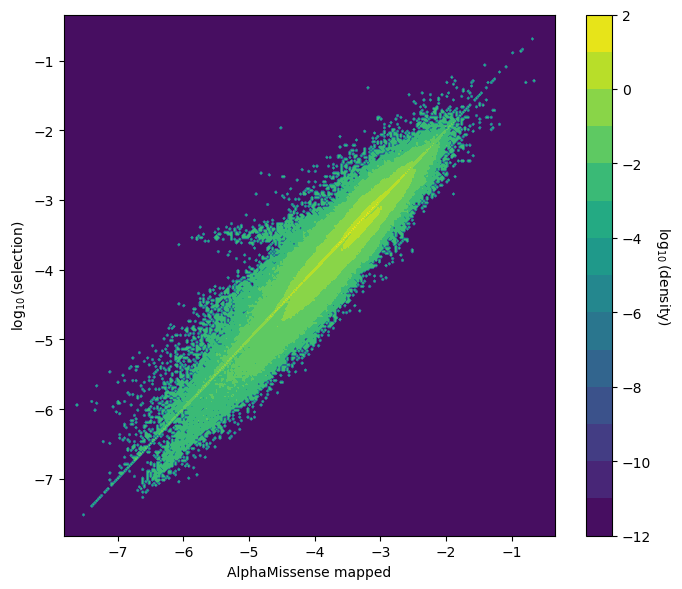

In [51]:
contour_from_points_logdensity(df_diff_nonna["popEVE"], 1-df_diff_nonna["popEVE_neg"])